In [39]:
import sys
import os
import pandas as pd

sys.path.append(os.path.abspath(os.path.join('..')))
from src.data.connection import get_db_connection


conn = get_db_connection()

if conn:
    query_tables = "SELECT table_name FROM information_schema.tables WHERE table_schema = 'raw';"
    tables = pd.read_sql(query_tables, conn)['table_name'].tolist()
    
    all_data = {}

    for table in tables:
        all_data[table] = pd.read_sql(f"SELECT * FROM raw.{table}", conn)
        print(f"Таблица '{table}' загружена! (строк: {len(all_data[table])})")
    
    conn.close()
else:
    print("Ошибка подключения к СУБД")



Успешно: Подключение к СУБД установлено.
Таблица 'train' загружена! (строк: 891)


C:\Users\NoutSpace\AppData\Local\Temp\ipykernel_18852\3567118331.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  tables = pd.read_sql(query_tables, conn)['table_name'].tolist()
C:\Users\NoutSpace\AppData\Local\Temp\ipykernel_18852\3567118331.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  all_data[table] = pd.read_sql(f"SELECT * FROM raw.{table}", conn)


Таблица 'titanic_income_transactions' загружена! (строк: 12183)
Таблица 'titanic_onboard_products' загружена! (строк: 30)
Таблица 'titanic_purchases' загружена! (строк: 17871)
Таблица 'gender_submission' загружена! (строк: 418)
Таблица 'test' загружена! (строк: 418)


In [3]:
train = all_data['train']
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,,S


In [28]:
train.drop(['PassengerId','Survived', 'Pclass'], axis=1).describe() 

,Age,SibSp,Parch,Fare
count,714.000000,891.000000,891.000000,891.000000
mean,29.699118,0.523008,0.381594,32.204208
std,14.526497,1.102743,0.806057,49.693429
min,0.420000,0.000000,0.000000,0.000000
25%,20.125000,0.000000,0.000000,7.910400
50%,28.000000,0.000000,0.000000,14.454200
75%,38.000000,1.000000,0.000000,31.000000
max,80.000000,8.000000,6.000000,512.329200


In [27]:
### Totala information about passengers by class
summary_by_class_gender = (
	train.assign(Is_Child=train["Age"] < 18)
	.groupby(["Pclass", "Sex"], observed=True)
	.agg(
		total_passengers=("PassengerId", "size"),
		children_count=("Is_Child", "sum"),
		survived_count=("Survived", "sum"),
	)
	.assign(
		died_count=lambda df: df["total_passengers"] - df["survived_count"],
		children_percentage=lambda df: (df["children_count"] / df["total_passengers"] * 100).round(2),
		survival_rate=lambda df: (df["survived_count"] / df["total_passengers"] * 100).round(2),
	)
	.reset_index()
)

summary_by_class_gender

,Pclass,Sex,total_passengers,children_count,survived_count,died_count,children_percentage,survival_rate
0,1,female,94,8,91,3,8.51,96.81
1,1,male,122,4,45,77,3.28,36.89
2,2,female,76,12,70,6,15.79,92.11
3,2,male,108,11,17,91,10.19,15.74
4,3,female,144,35,72,72,24.31,50.00
5,3,male,347,43,47,300,12.39,13.54


In [ ]:
### Table above shows all information about passengers by class and gender 
# we can see that the best survival metrics is for women in the first class, 
# and the worst is for men in the third class.

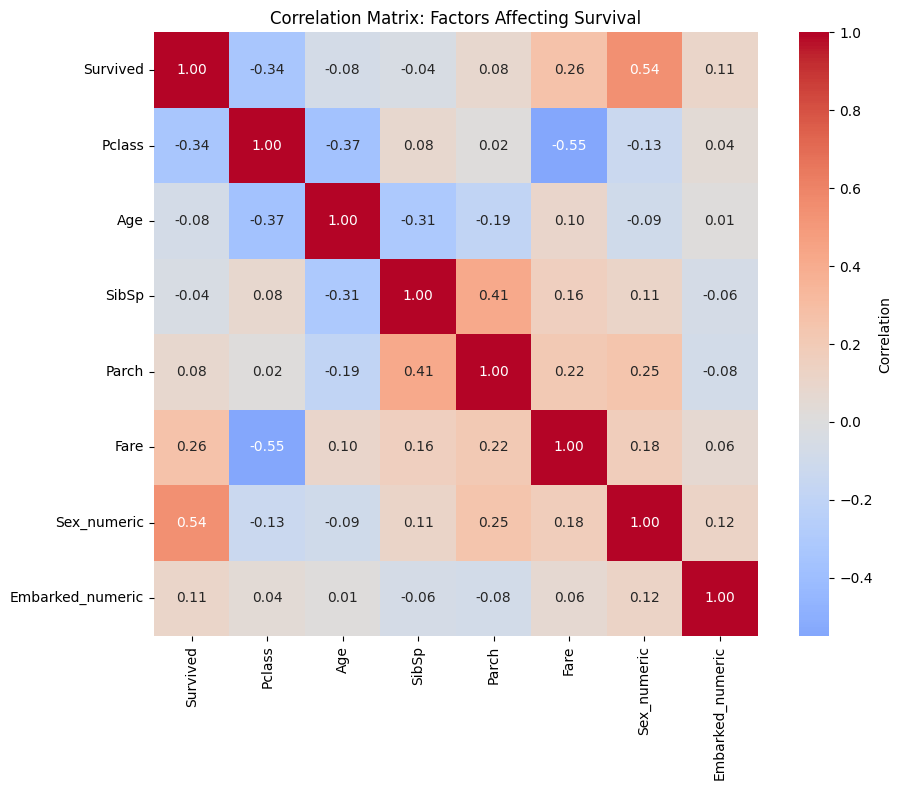

In [38]:
import seaborn as sns

import matplotlib.pyplot as plt
train_for_corr['Sex_numeric'] = (train_for_corr['Sex'] == 'female').astype(int)

embarked_mapping = {'S': 1, 'C': 2, 'Q': 3}
train_for_corr['Embarked_numeric'] = train_for_corr['Embarked'].map(embarked_mapping)

numerical_cols_with_gender_embarked = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_numeric', 'Embarked_numeric']

corr = train_for_corr[numerical_cols_with_gender_embarked].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix: Factors Affecting Survival')
plt.tight_layout()
plt.show()

In [ ]:
### correlation matrix shows that the most important factors affecting survival are sex, fare and class, 
# while age and parch have a weaker correlation with survival.

Text(0.5, 0, 'Gender')

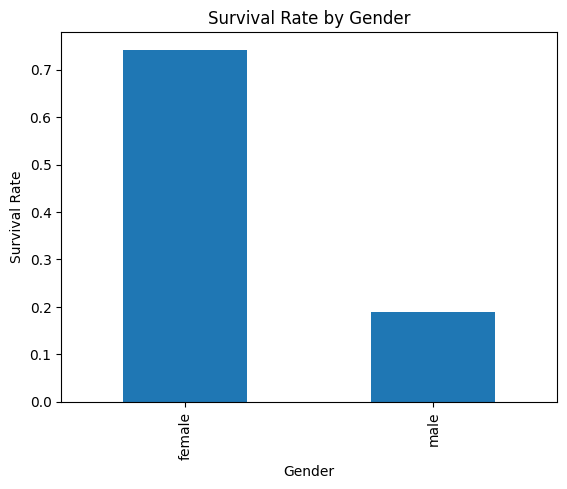

In [7]:
### Hypothesis: Females had a higher survival rate than males 
survival_rate_by_gender = train.groupby('Sex')['Survived'].mean()
ax = survival_rate_by_gender.plot(kind='bar', title='Survival Rate by Gender')
ax.set_ylabel('Survival Rate')
ax.set_xlabel('Gender')

Females had significanly higher survival rate than males 

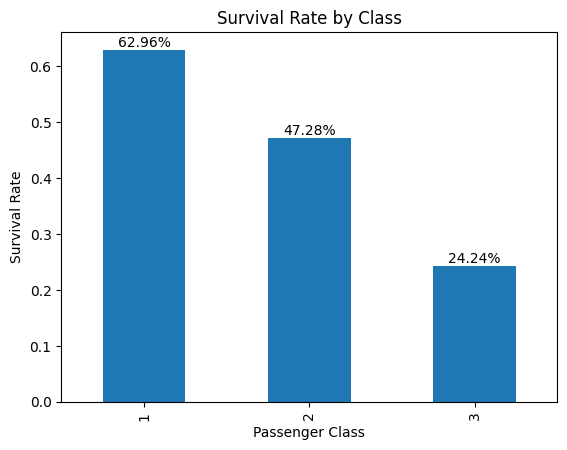

In [11]:
ax = survival_rate_by_class.plot(kind='bar', title='Survival Rate by Class')
ax.set_ylabel('Survival Rate')
ax.set_xlabel('Passenger Class')

for p in ax.patches:
    ax.annotate(
        f'{p.get_height() * 100:.2f}%',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom'
    )

1st class passendgers survived 62.96% which is maximum 

Text(0, 0.5, 'Survival Percentage (%)')

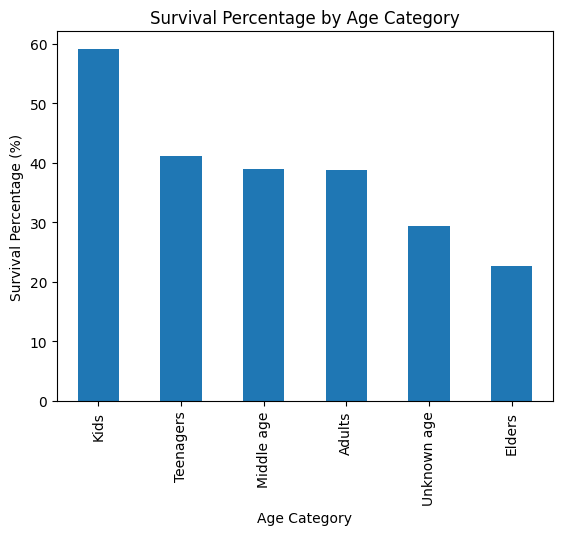

In [12]:
### survival rate depends on age category
age_category = pd.cut(
	train["Age"],
	bins=[-1, 13, 18, 40, 60, float("inf")],
	labels=["Kids", "Teenagers", "Adults", "Middle age", "Elders"],
)
age_category = age_category.cat.add_categories(["Unknown age"]).fillna("Unknown age")

age_stats = (
	train.assign(Age_Category=age_category)
	.groupby("Age_Category", observed=True)
	.agg(
		total_passengers=("PassengerId", "size"),
		survival_percentage=("Survived", lambda x: x.mean() * 100),
	)
	.reset_index()
	.sort_values("survival_percentage", ascending=False)
)

ax = age_stats.plot.bar(
	x="Age_Category",
	y="survival_percentage",
	title="Survival Percentage by Age Category",
	legend=False,
)
ax.set_xlabel("Age Category")
ax.set_ylabel("Survival Percentage (%)")

In the graph we can see that kids and teenagers had higher survival rate than others 

         Family_Group  total_passengers  survival_percentage
1  With family member               354            50.564972
0               Alone               537            30.353818


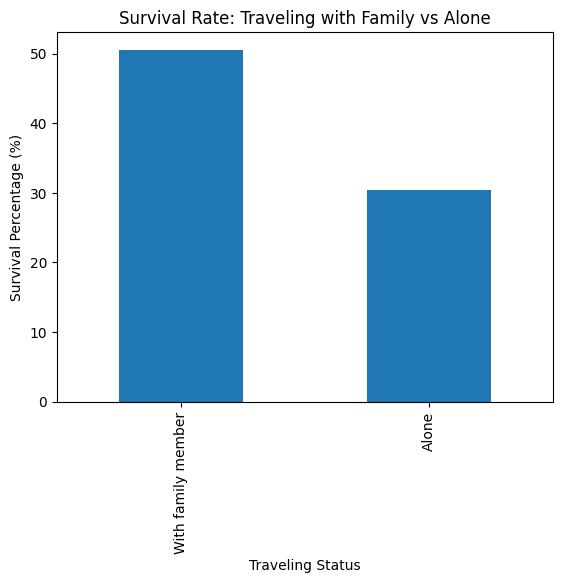

In [13]:
# Hypothesis: Passengers traveling with family members had a higher survival rate than those traveling alone
train['Family_Group'] = train.apply(
	lambda row: 'With family member' if (row['Parch'] + row['SibSp']) > 0 else 'Alone',
	axis=1
)

family_stats = (
	train.groupby('Family_Group')
	.agg(
		total_passengers=('PassengerId', 'size'),
		survival_percentage=('Survived', lambda x: x.mean() * 100)
	)
	.reset_index()
	.sort_values('survival_percentage', ascending=False)
)

ax = family_stats.plot.bar(
	x='Family_Group',
	y='survival_percentage',
	title='Survival Rate: Traveling with Family vs Alone',
	legend=False
)
ax.set_xlabel('Traveling Status')
ax.set_ylabel('Survival Percentage (%)')
print(family_stats)

Survival rate for passengers who were traveling with one or more family member is higher than those who travelling alone 

,Traveling_person_numb,total_passengers,survival_percentage
0,Other,844,39.691943
1,With 4 or more family member,47,14.893617


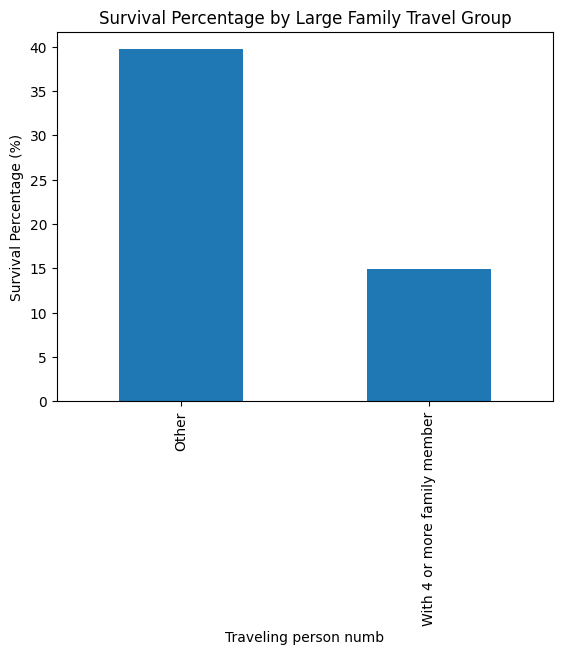

In [ ]:
### Hypothesis: Passengers traveling with 4 or more family members had a lower survival rate than those traveling with fewer family members
train['Traveling_person_numb'] = train.apply(
	lambda row: 'With 4 or more family member' if (row['Parch'] + row['SibSp']) > 4 else 'Other',
	axis=1
)

family_size_stats = (
	train.groupby('Traveling_person_numb')
	.agg(
		total_passengers=('PassengerId', 'size'),
		survival_percentage=('Survived', lambda x: x.mean() * 100)
	)
	.reset_index()
	.sort_values('survival_percentage', ascending=False)
)

ax = family_size_stats.plot.bar(
	x='Traveling_person_numb',
	y='survival_percentage',
	title='Survival Percentage by Large Family Travel Group',
	legend=False
)
ax.set_xlabel('Traveling person numb')
ax.set_ylabel('Survival Percentage (%)')
family_size_stats

Passengers traveling with 4 or more family members were 47, but their survival rate is 14.89% which means only 7 of them were saved 

,Embarked,total_passengers,survival_percentage
0,,2,100.000000
1,C,168,55.357143
2,Q,77,38.961039
3,S,644,33.695652


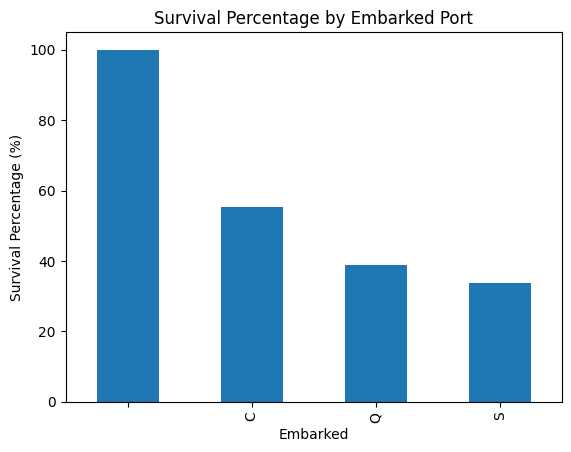

In [ ]:
### Hypothesis: Passengers who embarked from certain ports had different survival rates
embarked_stats = (
	train.assign(Embarked=train["Embarked"].fillna("Unknown"))
	.groupby("Embarked", observed=True)
	.agg(
		total_passengers=("PassengerId", "size"),
		survival_percentage=("Survived", lambda x: x.mean() * 100),
	)
	.reset_index()
	.sort_values("survival_percentage", ascending=False)
)

ax = embarked_stats.plot.bar(
	x="Embarked",
	y="survival_percentage",
	title="Survival Percentage by Embarked Port",
	legend=False,
)
ax.set_xlabel("Embarked")
ax.set_ylabel("Survival Percentage (%)")
embarked_stats

2 passengers with no recorded embarked port survived and Cherbourg passengers sirvived more with rate 55.35% 

,fare_bracket,total_passengers,survival_rate_pct
0,Staff,15,6.67
1,Low cost,321,20.56
2,Medium cost,321,43.30
3,High cost,181,53.59
4,100+ Luxury,53,73.58


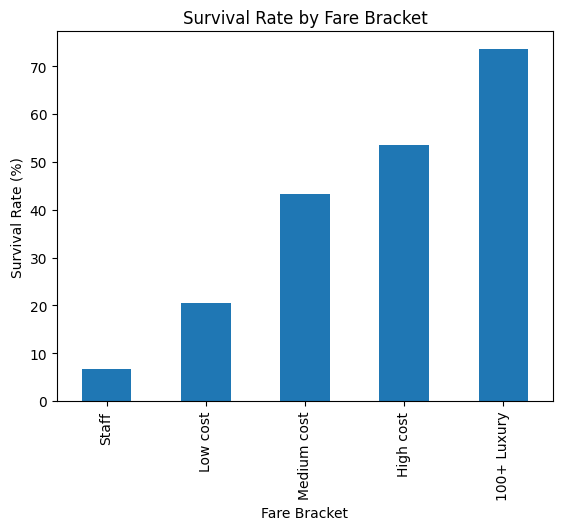

In [ ]:
### Hypothesis: Passengers who paid higher fares had a higher survival rate than those who paid lower fares
fare_bracket = pd.cut(
    train["Fare"],
    bins=[-0.01, 0, 10, 30, 100, train["Fare"].max()],
    labels=["Staff", "Low cost", "Medium cost", "High cost", "100+ Luxury"],
)

fare_bracket_stats = (
    train.assign(fare_bracket=fare_bracket)
    .groupby("fare_bracket", observed=True)
    .agg(
        total_passengers=("PassengerId", "size"),
        survival_rate_pct=("Survived", lambda x: round(x.mean() * 100, 2)),
    )
    .reset_index()
)

ax = fare_bracket_stats.plot.bar(
    x="fare_bracket",
    y="survival_rate_pct",
    title="Survival Rate by Fare Bracket",
    legend=False,
)
ax.set_xlabel("Fare Bracket")
ax.set_ylabel("Survival Rate (%)")
fare_bracket_stats


Survival rate for passengers who paid 100+ luxury fare was the highest, while those who paid low cost had the lowest survival rate. This suggests that passengers in higher fare brackets may have had better access to lifeboats or were prioritized during evacuation, while those in lower fare brackets may have been located in less accessible areas of the ship or had fewer resources available to them.

Survived,0,1
Pclass,,
1,1,11
2,2,21
3,49,29


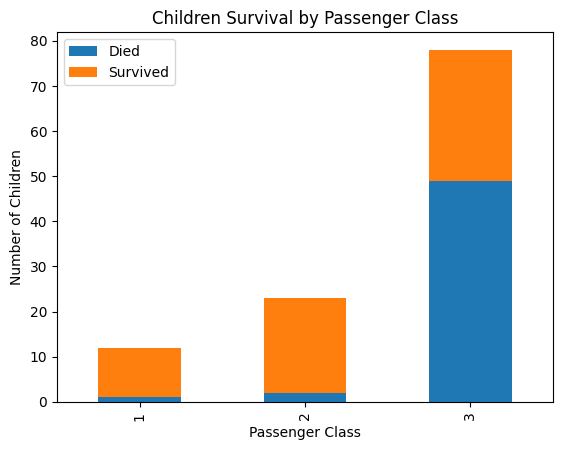

In [ ]:
##Hypothesis: survival rate depends on passenger class even for children under 18
children = train[train['Age'] < 18]
children_stats = children.groupby(['Pclass', 'Survived']).size().unstack(fill_value=0)
ax = children_stats.plot(kind='bar', stacked=True, title='Children Survival by Passenger Class')
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Number of Children')
ax.legend(['Died', 'Survived'])
children_stats


we can see that even among children, those in higher classes had a better chance of survival, which suggests that passenger class influenced survival rates regardless of age.